In [2]:
# def train_model(model,d, optimizer ,data_loader, loss_module, num_epochs=100):
#     model.train()
#     train_losses  = []
#     for epoch in tqdm(range(num_epochs)):
#         for data_inputs, data_labels in data_loader:
#             # Put training data into GPU
#             data_inputs = data_inputs.to(device)
#             data_labels = data_labels.to(device)

#             preds = model(data_inputs).to(device)
#             loss  = loss_module(preds, data_labels)
#             train_losses.append(loss.item())

#             # Zero the gradients
#             optimizer.zero_grad()
#             loss     .backward()
#             optimizer.step()

#     return train_losses

In [1]:
from torch.utils.data import DataLoader, TensorDataset, Dataset
from IPython import display
from copy import deepcopy
from math import floor
from tqdm import tqdm

import matplotlib.pyplot   as plt
import torch.nn            as nn
import torch.nn.functional as F
import numpy               as np
import random
import torch

random.seed(42)

In [2]:
torch.manual_seed(seed = 42)
# device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
device = torch.device('cpu')
print(device)

cpu


In [5]:
# sample_uniform = lambda : random.uniform(-2*np.pi, 2*np.pi)
sample_uniform = lambda : random.uniform(-5, 5)

In [6]:
def train_model(model,d, optimizer ,data_loader, loss_module, num_epochs=100):
    model.train()
    train_losses  = []
    for epoch in tqdm(range(num_epochs)):
        for data_inputs, data_labels in data_loader:
            # Put training data into GPU
            data_inputs = data_inputs.to(d)
            data_labels = data_labels.to(d)

            preds = model(data_inputs)
            loss  = loss_module(preds, data_labels)
            train_losses.append(loss.item())

            # Zero the gradients
            optimizer.zero_grad()
            loss     .backward()
            optimizer.step()

    return train_losses

In [7]:
class CustomSinDataset(Dataset):
    def __init__(self, phase_shift: float | None = None, period_shift: float | None = None, n_samples: int | None = 100):
        """
        https://www.mathsisfun.com/algebra/amplitude-period-frequency-phase-shift.html
        https://www.youtube.com/watch?v=wT45v8sIMDM&t=3s
        """
        # self.phase_shift  = phase_shift  if not phase_shift  else sample_uniform()
        # self.period_shift = period_shift if not period_shift else sample_uniform()
        self.n = n_samples

        self.c1 = self.__generate_curve__()

        self.X_list = [sample_uniform() for _ in range(self.n)]
        self.Y_list = [self.c1(x) for x in self.X_list]

        self.X = torch.from_numpy(np.array(self.X_list)).type(torch.float32).unsqueeze(dim = 1)
        self.Y = torch.from_numpy(np.array(self.Y_list)).type(torch.float32).unsqueeze(dim = 1)

    def __len__(self):
        return len(self.X)
    
    def __generate_curve__(self):
        # shift  = random.uniform(-2*np.pi, 2*np.pi)
        # period = random.randint(1,6)
        amplittude = random.uniform(0.1,0.5)
        phase = random.uniform(0,np.pi)
        return lambda x: amplittude * np.sin( (x - phase) )

    def __getitem__(self, idx):
        return self.X[idx],self.Y[idx]

    def plot(self, model = None):
        line_space = np.linspace(start=-2*np.pi,stop= 2*np.pi,num = 100)
        plt.plot(line_space,[self.c1(x) for x in line_space])
        plt.scatter(self.X_list,self.Y_list, c = 'r')
        plt.grid(visible=True)

        if model:
            model.eval()
            line_space_tensor = torch.from_numpy(np.array(line_space)).type(torch.float32).unsqueeze(dim = 1)
            plt.scatter(line_space, [model(x).item() for x in line_space_tensor], c = 'b')
            plt.grid(visible=True)
        plt.show()

In [8]:
model = nn.Sequential(
    nn.Linear(1, 40),
    nn.ReLU(),
    nn.Linear(40, 40),
    nn.ReLU(),
    nn.Linear(40, 1),
)

loss_module = torch.nn.MSELoss()
optimizer   = torch.optim.Adam(model.parameters(), lr=0.01, betas = (0.9,0.99)) #(0.1,0.3)

In [9]:
tasks         = [CustomSinDataset(n_samples=10) for _ in range(70_000)]
tasks_loaders = [DataLoader(t,batch_size=len(t),shuffle=False) for t in tasks]

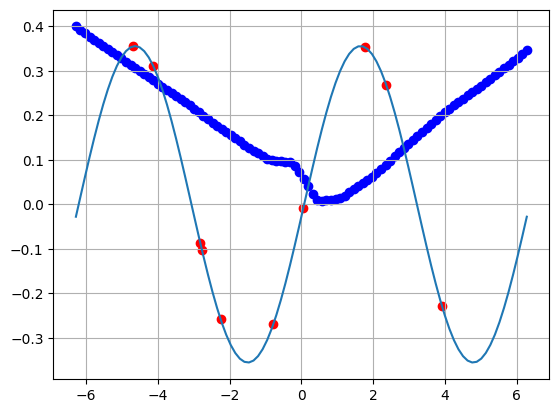

In [10]:
tasks[0].plot(model = model)

In [11]:
model.to(device)

Sequential(
  (0): Linear(in_features=1, out_features=40, bias=True)
  (1): ReLU()
  (2): Linear(in_features=40, out_features=40, bias=True)
  (3): ReLU()
  (4): Linear(in_features=40, out_features=1, bias=True)
)

In [12]:
train_losses  = []

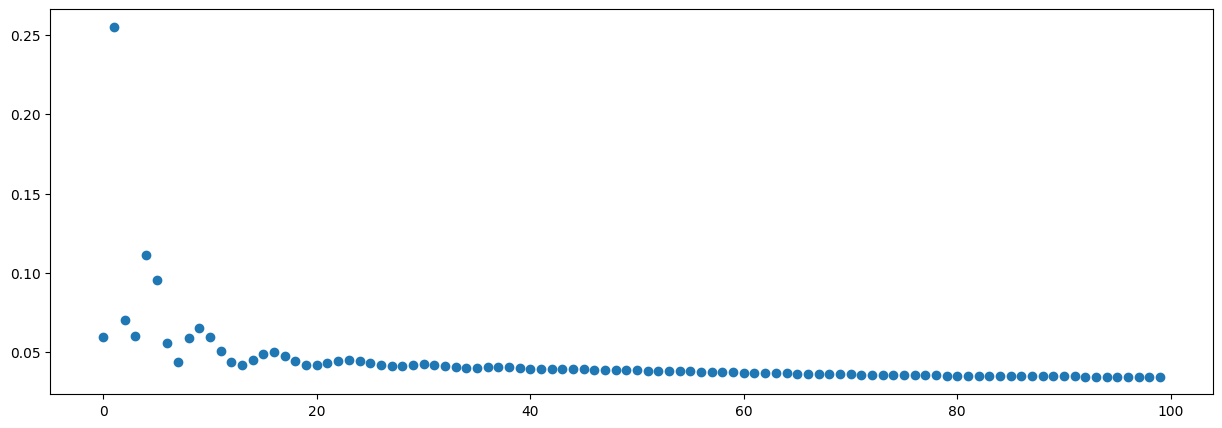

In [13]:
for rounds in (range(100)):
    optimizer.zero_grad()
    total_loss = 0
    count      = 0
    for task in tasks_loaders:
        for data_inputs, data_labels in task:
            data_inputs = data_inputs.to(device)
            data_labels = data_labels.to(device)

            preds = model(data_inputs)
            loss     = loss_module(preds, data_labels)
            # Add up all the gradients
            loss.backward()
            total_loss += loss.item()
            count += 1
    train_losses.append(total_loss / count)
    optimizer.step()
    display.clear_output(wait=True)
    plt.figure(figsize=(15,5))
    plt.scatter([i for i, _ in enumerate(train_losses)],train_losses)
    plt.show()
# 1 minute 26

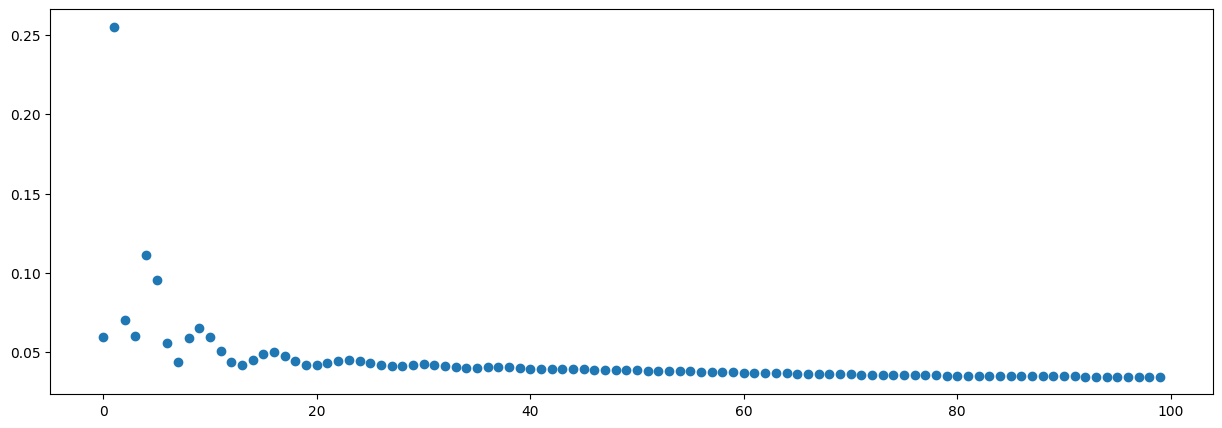

In [22]:
plt.figure(figsize=(15,5))
plt.scatter([i for i, _ in enumerate(train_losses)],train_losses)
plt.show()

In [15]:
model.to(device = torch.device('cpu'))

Sequential(
  (0): Linear(in_features=1, out_features=40, bias=True)
  (1): ReLU()
  (2): Linear(in_features=40, out_features=40, bias=True)
  (3): ReLU()
  (4): Linear(in_features=40, out_features=1, bias=True)
)

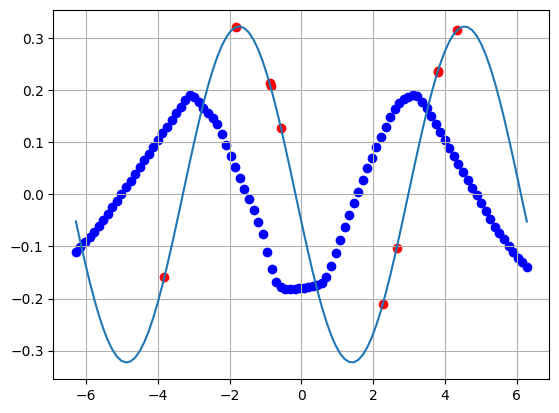

In [27]:
tasks[400].plot(model = model)

In [33]:
m = deepcopy(model)

In [34]:
D1 = CustomSinDataset(n_samples=100)
D1_train = DataLoader(D1, batch_size = len(D1), shuffle = False)

100%|██████████| 10/10 [00:00<00:00, 258.21it/s]


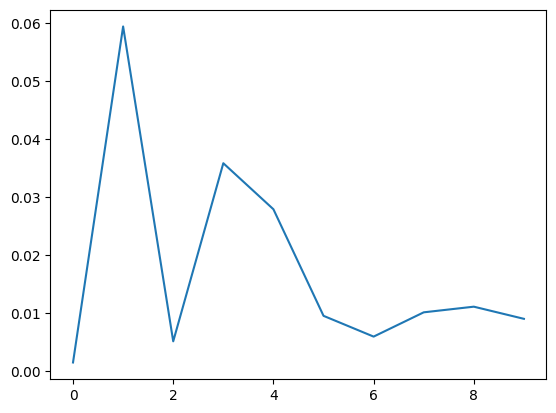

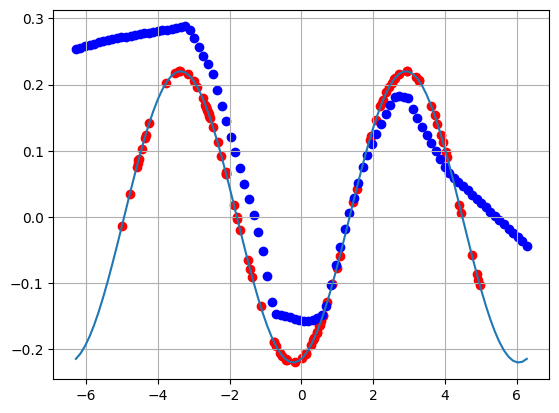

In [35]:
m.to(torch.device('cpu'))

loss_module = torch.nn.MSELoss()
optimizer   = torch.optim.Adam(m.parameters(), lr=0.01, betas = (0.9,0.99))

history = train_model(
    model       = m,
    d           = torch.device('cpu'),
    optimizer   = optimizer,
    data_loader = D1_train,
    loss_module = loss_module,
    num_epochs  = 10
)
plt.plot(history)
plt.show()
D1.plot(model = m)

---

In [36]:
m2 = nn.Sequential(
    nn.Linear(1, 40),
    nn.ReLU(),
    nn.Linear(40, 40),
    nn.ReLU(),
    nn.Linear(40, 1),
)

100%|██████████| 3/3 [00:00<00:00, 242.06it/s]


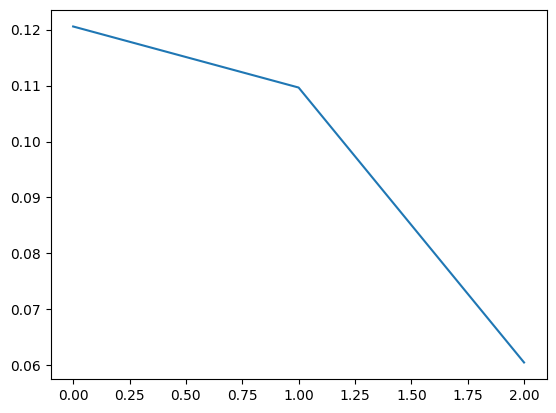

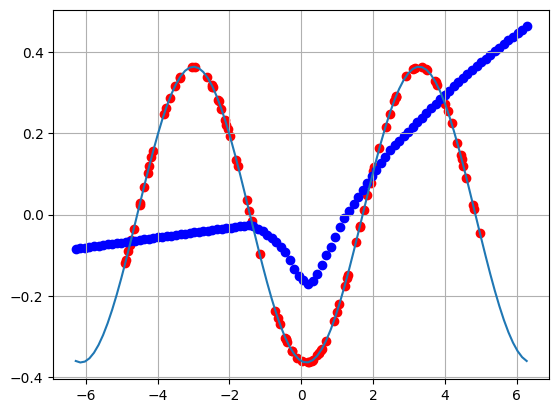

In [ ]:
m2.to(torch.device('cpu'))

loss_module = torch.nn.MSELoss()
optimizer   = torch.optim.Adam(m2.parameters(), lr=0.01, betas = (0.9,0.99))

history = train_model(
    model       = m2,
    d           = torch.device('cpu'),
    optimizer   = optimizer,
    data_loader = D1_train,
    loss_module = loss_module,
    num_epochs  = 10
)
plt.plot(history)
plt.show()
D1.plot(model = m2)